In [2]:
import numpy as np
import pandas as pd


df = pd.read_csv(
    'vgsales.csv',
    dtype={
        "Rank": np.int16,
        "NA_Sales": np.float32,
        "EU_Sales": np.float32,
        "JP_Sales":	np.float32,
        "Other_Sales": np.float32,
        "Global_Sales": np.float32,
    },
    index_col=0
)
df

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Rank,,,,,,,,,,
1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.490002,29.02,3.77,8.46,82.739998
2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.080000,3.58,6.81,0.77,40.240002
3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.850000,12.88,3.79,3.31,35.820000
4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.750000,11.01,3.28,2.96,33.000000
5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.270000,8.89,10.22,1.00,31.370001
...,...,...,...,...,...,...,...,...,...,...
16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.010000,0.00,0.00,0.00,0.010000
16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.010000,0.00,0.00,0.00,0.010000
16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.000000,0.00,0.00,0.00,0.010000


In [3]:
df.dropna(inplace=True)
df.isna().sum()

Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [4]:
df['Year'] = df['Year'].fillna(0)
df['Publisher'] = df['Publisher'].fillna('Unknown')

In [5]:
df['Year'] = df['Year'].astype(np.int16)

In [6]:
sales_columns = df[['NA_Sales', "EU_Sales", 'JP_Sales', "Other_Sales"]]
calculated_global_sales = sales_columns.sum(axis=1).round(2)
mean_global_sales = sales_columns.mean(axis=1).round(2)
df.insert(10, 'Calculated_Global_Sales', calculated_global_sales)
df.insert(11, 'Mean_Global_Sales', mean_global_sales)
df.head()

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Calculated_Global_Sales,Mean_Global_Sales
Rank,,,,,,,,,,,,
1,Wii Sports,Wii,2006,Sports,Nintendo,41.490002,29.02,3.77,8.46,82.739998,82.739998,20.68
2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.080000,3.58,6.81,0.77,40.240002,40.240002,10.06
3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.850000,12.88,3.79,3.31,35.820000,35.830002,8.96
4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.750000,11.01,3.28,2.96,33.000000,33.000000,8.25
5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.270000,8.89,10.22,1.00,31.370001,31.379999,7.84


In [13]:
global_sales = df.loc[(df["Publisher"] == "Nintendo") | (df["Publisher"] == "Activision"), ["Publisher", "Calculated_Global_Sales"]]
global_sales.groupby("Publisher").sum()

,Calculated_Global_Sales
Publisher,
Activision,721.059998
Nintendo,1784.229980


In [8]:
global_sales = df.loc[(df["Publisher"] == "Nintendo") | (df["Publisher"] == "Activision"), ["Publisher", "Mean_Global_Sales"]]
global_sales.groupby("Publisher").sum()

,Mean_Global_Sales
Publisher,
Activision,179.850006
Nintendo,445.970001


In [9]:
global_sales = df.loc[(df["Platform"] == "PS4") | (df["Platform"] == "X360") | (df["Platform"] == "PC") , ["Platform", "Mean_Global_Sales"]]
global_sales.groupby("Platform").sum()

,Mean_Global_Sales
Platform,
PC,62.310001
PS4,69.459999
X360,242.000000


In [10]:
global_sales = df.loc[(df["Platform"] == "PS4") | (df["Platform"] == "X360") | (df["Platform"] == "PC") , ["Platform", "Calculated_Global_Sales"]]
global_sales.groupby("Platform").sum()

,Calculated_Global_Sales
Platform,
PC,253.889999
PS4,278.160004
X360,969.299988


<Axes: xlabel='Genre'>

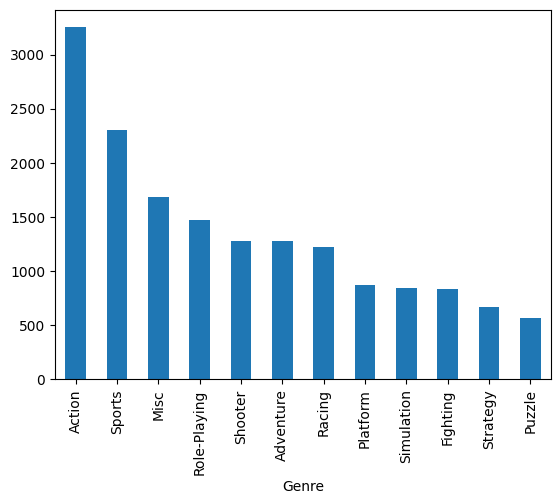

In [11]:
df['Genre'].value_counts().plot(kind='bar')

In [12]:
df

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Calculated_Global_Sales,Mean_Global_Sales
Rank,,,,,,,,,,,,
1,Wii Sports,Wii,2006,Sports,Nintendo,41.490002,29.02,3.77,8.46,82.739998,82.739998,20.68
2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.080000,3.58,6.81,0.77,40.240002,40.240002,10.06
3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.850000,12.88,3.79,3.31,35.820000,35.830002,8.96
4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.750000,11.01,3.28,2.96,33.000000,33.000000,8.25
5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.270000,8.89,10.22,1.00,31.370001,31.379999,7.84
...,...,...,...,...,...,...,...,...,...,...,...,...
16596,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.010000,0.00,0.00,0.00,0.010000,0.010000,0.00
16597,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.010000,0.00,0.00,0.00,0.010000,0.010000,0.00
16598,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.000000,0.00,0.00,0.00,0.010000,0.000000,0.00
